# 微積分與最佳化 (Calculus & Optimization)

學習目標：
- 了解微分的直覺概念
- 理解梯度下降是什麼
- 用 Python 實作梯度下降

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. 微分直覺

導數 = 函數在某點的斜率 = 瞬間變化率

運動員例子：
訓練量和成績的關係：
- 導數為正 → 增加訓練量，成績上升
- 導數為零 → 到達最佳訓練量
- 導數為負 → 訓練過量，成績下降

解析導數 at x=2.0: 7.0
數值導數 at x=2.0: 7.000000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


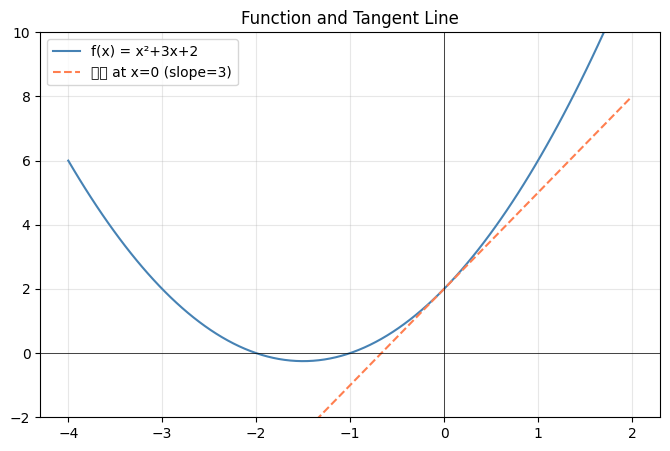

In [2]:
# 定義函數和導數
def f(x):
    return x**2 + 3*x + 2

def df(x):      # 解析導數
    return 2*x + 3

# 數值微分（近似導數）
def numerical_diff(f, x, h=1e-5):
    return (f(x+h) - f(x-h)) / (2*h)

x = 2.0
print(f'解析導數 at x={x}: {df(x)}')
print(f'數值導數 at x={x}: {numerical_diff(f, x):.6f}')

# 畫函數和切線
x_range = np.linspace(-4, 2, 100)
plt.figure(figsize=(8, 5))
plt.plot(x_range, f(x_range), 'steelblue', label='f(x) = x²+3x+2')

# 在 x=0 畫切線
x0 = 0
slope = df(x0)
tangent = f(x0) + slope * (x_range - x0)
plt.plot(x_range, tangent, 'coral', linestyle='--',
         label=f'切線 at x={x0} (slope={slope})')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.ylim(-2, 10)
plt.legend()
plt.title('Function and Tangent Line')
plt.grid(alpha=0.3)
plt.show()

## 2. 梯度下降 (Gradient Descent)

最佳化的核心：找函數的最小值。

步驟：
1. 從任意點出發
2. 計算該點的斜率（梯度）
3. 往斜率反方向移動一小步
4. 重複直到斜率接近0

深度學習訓練就是用梯度下降
找讓損失函數最小的權重。

In [3]:
# 實作梯度下降
def gradient_descent(start, lr, n_iter):
    x = start
    history = [x]
    for _ in range(n_iter):
        grad = df(x)          # 計算梯度
        x = x - lr * grad     # 往反方向移動
        history.append(x)
    return x, history

# 執行梯度下降
x_min, history = gradient_descent(
    start=2.0, lr=0.1, n_iter=50)

print(f'最小值位於 x = {x_min:.4f}')
print(f'理論最小值 x = {-3/2}')
print(f'最小值 f(x) = {f(x_min):.4f}')

最小值位於 x = -1.5000
理論最小值 x = -1.5
最小值 f(x) = -0.2500


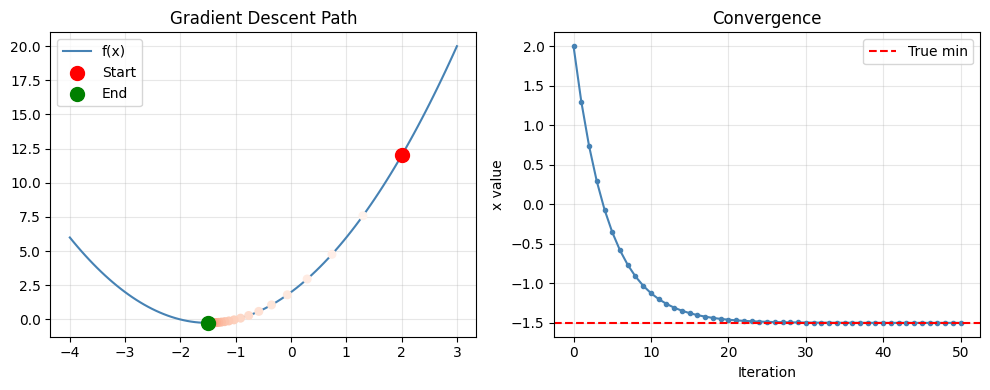

In [4]:
# 視覺化梯度下降過程
x_range = np.linspace(-4, 3, 100)

plt.figure(figsize=(10, 4))

# 左圖：路徑
plt.subplot(1, 2, 1)
plt.plot(x_range, f(x_range), 'steelblue', label='f(x)')
plt.scatter(history, [f(x) for x in history],
            c=range(len(history)), cmap='Reds', s=30, zorder=5)
plt.scatter(history[0], f(history[0]),
            color='red', s=100, label='Start', zorder=6)
plt.scatter(history[-1], f(history[-1]),
            color='green', s=100, label='End', zorder=6)
plt.legend()
plt.title('Gradient Descent Path')
plt.grid(alpha=0.3)

# 右圖：x 收斂過程
plt.subplot(1, 2, 2)
plt.plot(history, 'steelblue', marker='o', markersize=3)
plt.axhline(y=-1.5, color='red', linestyle='--', label='True min')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Convergence')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 學習率的影響

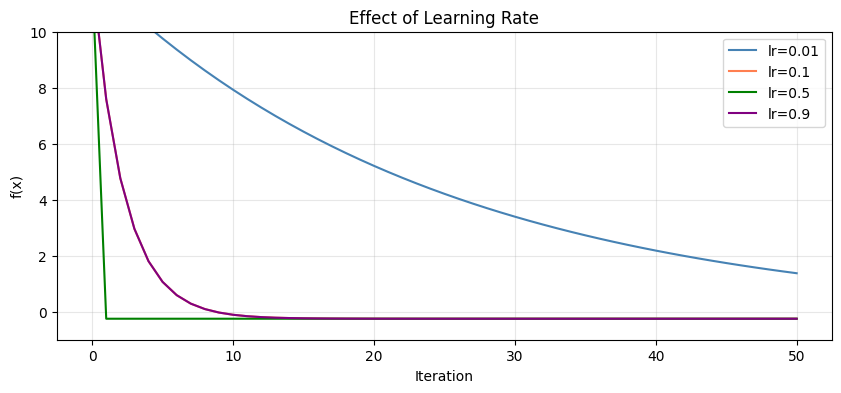

In [5]:
# 比較不同學習率
learning_rates = [0.01, 0.1, 0.5, 0.9]
colors = ['steelblue', 'coral', 'green', 'purple']

plt.figure(figsize=(10, 4))
for lr, color in zip(learning_rates, colors):
    _, hist = gradient_descent(start=2.0, lr=lr, n_iter=50)
    plt.plot([f(x) for x in hist],
             color=color, label=f'lr={lr}')

plt.xlabel('Iteration')
plt.ylabel('f(x)')
plt.title('Effect of Learning Rate')
plt.legend()
plt.ylim(-1, 10)
plt.grid(alpha=0.3)
plt.show()

## 4. 我的學習筆記

1. 這個主題在做什麼：
   微分計算函數的斜率，
   梯度下降用斜率資訊找函數最小值，
   這是深度學習訓練的核心機制。

2. 學習率的重要性：
   - 太小 → 收斂很慢
   - 太大 → 震盪無法收斂
   - 剛好 → 快速穩定收斂

3. 我覺得最難理解的地方：
   000
4. 這個跟我研究的連結：
   訓練運動員表現預測模型時，
   梯度下降負責調整模型的權重，
   學習率的設定直接影響訓練效果。